# Wastewater surveillance, CDC NWSS (Lane A: you prompt, the agent builds)

**SISMID 2026 - Day 2, 9:00.** Drive **Codex / Claude Code / Antigravity CLI**. Each prompt
produces roughly the matching Lane B cell. Not set up? Use Lane B.


## Step 0: point the agent at the task
 *From CDC's National Wastewater Surveillance System open data on data.cdc.gov (the 'CDC-Wastewater-Data-for-Measles' dataset, Socrata id `akvg-8vrb`), write `nwss_fetch()` that returns a tidy DataFrame for all states aggregated to state level, and a national aggregate. Add `get_measles_wastewater()` that pulls all locations, parses the collection date, sums to national level by each collection date, coerces `pcr_target_avg_conc` to numeric*

In [2]:
import pandas as pd
import requests

NWSS_MEASLES_URL = 'https://data.cdc.gov/resource/akvg-8vrb.json'

def get_measles_wastewater(page_size=50_000):
    """Return daily state totals plus a national total from CDC measles NWSS data."""
    fields = ['sample_collect_date', 'state_territory', 'site', 'population_served',
              'pcr_target_avg_conc']
    rows, offset = [], 0
    while True:
        response = requests.get(
            NWSS_MEASLES_URL,
            params={'$select': ','.join(fields), '$limit': page_size,
                    '$offset': offset, '$order': 'record_id'},
            timeout=60,
        )
        response.raise_for_status()
        page = response.json()
        rows.extend(page)
        if len(page) < page_size:
            break
        offset += page_size

    samples = pd.DataFrame(rows, columns=fields)
    samples['collection_date'] = pd.to_datetime(
        samples.pop('sample_collect_date'), errors='coerce', utc=True
    ).dt.tz_localize(None).dt.normalize()
    samples['pcr_target_avg_conc'] = pd.to_numeric(
        samples['pcr_target_avg_conc'], errors='coerce'
    )
    samples['population_served'] = pd.to_numeric(
        samples['population_served'], errors='coerce'
    )
    samples = samples.dropna(subset=['collection_date', 'state_territory'])
    weekly_national_sites = (
        samples.groupby(pd.Grouper(key='collection_date', freq='W-SUN'), as_index=False)
        .agg(n_sites_reporting=('site', 'nunique'))
    )

    state_totals = (
        samples.groupby(['collection_date', 'state_territory'], as_index=False)
        .agg(pcr_target_avg_conc=('pcr_target_avg_conc', 'sum'),
             population_served=('population_served', 'sum'))
        .assign(geography='state')
    )
    national = (
        samples.groupby('collection_date', as_index=False)
        .agg(pcr_target_avg_conc=('pcr_target_avg_conc', 'sum'),
             population_served=('population_served', 'sum'))
        .assign(state_territory='National', geography='national')
    )
    result = (pd.concat([state_totals, national], ignore_index=True)
              .sort_values(['collection_date', 'geography', 'state_territory'])
              .reset_index(drop=True))
    result.attrs['weekly_national_sites'] = weekly_national_sites
    return result


def nwss_fetch():
    """Fetch a tidy measles NWSS table for every state and the national aggregate."""
    return get_measles_wastewater()


## Step 1: pull measles wastewater

> *Use get_measles_wastewater(); print the row count, date range, and number of distinct date-state entries, and show a few rows with the  population served.*


In [4]:
ww = get_measles_wastewater()
state_rows = ww[ww['geography'].eq('state')]
print('rows:', len(ww))
print('date range:', ww['collection_date'].min().date(), 'to',
      ww['collection_date'].max().date())
print('distinct date-state entries:',
      state_rows[['collection_date', 'state_territory']].drop_duplicates().shape[0])
display(ww[['collection_date', 'state_territory', 'population_served',
            'pcr_target_avg_conc', 'geography']].head())


rows: 11961
date range: 2024-12-09 to 2026-07-14
distinct date-state entries: 11482


,collection_date,state_territory,population_served,pcr_target_avg_conc,geography
0,2024-12-09,National,1094955,218.22,national
1,2024-12-09,tx,1094955,218.22,state
2,2024-12-16,National,1094955,221.31,national
3,2024-12-16,tx,1094955,221.31,state
4,2025-01-27,National,762633,0.00,national


## Step 2: aggregate to a weekly state signal

> *Please aggregate to a weekly signal by state, and nationally, then create a "spaghetti" plot over time with each state as a light line and the national signal average as a darker line over time*




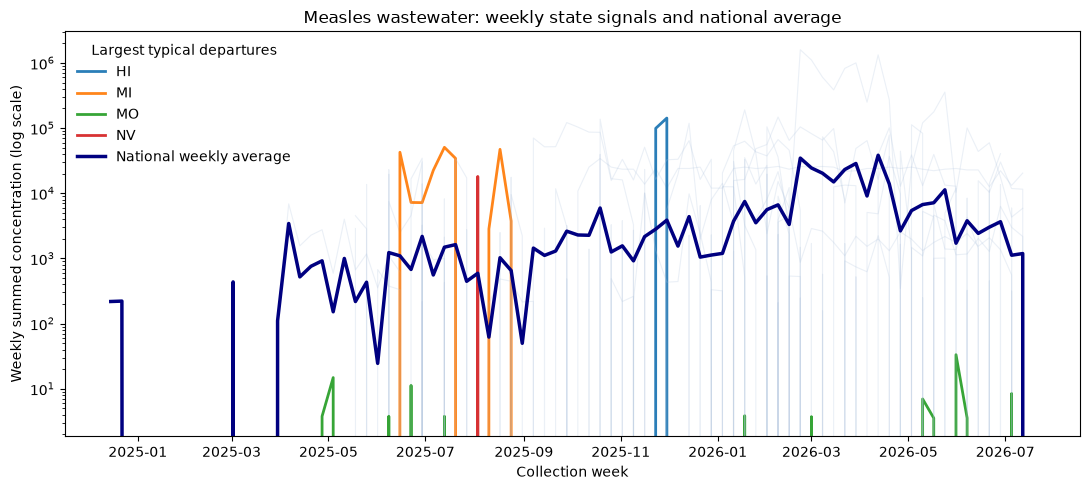

In [16]:
import matplotlib.pyplot as plt
import numpy as np

state_weekly = (
    ww[ww['geography'].eq('state')]
    .groupby([pd.Grouper(key='collection_date', freq='W-SUN'), 'state_territory'],
             as_index=False)['pcr_target_avg_conc']
    .sum()
)
national_weekly = (
    state_weekly.groupby('collection_date', as_index=False)['pcr_target_avg_conc']
    .mean()
)
national_aggregate_weekly = (
    ww[ww['geography'].eq('national')]
    .groupby(pd.Grouper(key='collection_date', freq='W-SUN'), as_index=False)
    ['pcr_target_avg_conc'].sum()
)
comparison = state_weekly.merge(
    national_weekly, on='collection_date', suffixes=('_state', '_average')
)
comparison['relative_to_average'] = (
    comparison['pcr_target_avg_conc_state']
    / comparison['pcr_target_avg_conc_average'].replace(0, np.nan)
)
state_departure = (
    comparison.assign(log_departure=np.log(comparison['relative_to_average'].where(
        comparison['relative_to_average'] > 0
    )).abs())
    .groupby('state_territory')['log_departure'].median()
    .nlargest(4)
)
highlight_states = set(state_departure.index)

highlight_colors = dict(zip(
    sorted(highlight_states), plt.colormaps['tab10'](range(len(highlight_states)))
))
fig, ax = plt.subplots(figsize=(11, 5))
for state, state_data in state_weekly.groupby('state_territory'):
    is_highlight = state in highlight_states
    ax.plot(state_data['collection_date'], state_data['pcr_target_avg_conc'],
            color=highlight_colors[state] if is_highlight else 'lightsteelblue',
            alpha=0.95 if is_highlight else 0.25,
            linewidth=2 if is_highlight else 0.8,
            label=state.upper() if is_highlight else None)
ax.plot(national_weekly['collection_date'],
        national_weekly['pcr_target_avg_conc'],
        color='navy', linewidth=2.5, label='National weekly average')
ax.set_yscale('log')
ax.set(title='Measles wastewater: weekly state signals and national average',
       xlabel='Collection week', ylabel='Weekly summed concentration (log scale)')
ax.legend(title='Largest typical departures', frameon=False)
fig.tight_layout()
plt.show()


## Step 3: single site vs aggregate

> *Overlay the single largest-population state against the national weekly mean, so I can see*
> *why aggregation matters.*


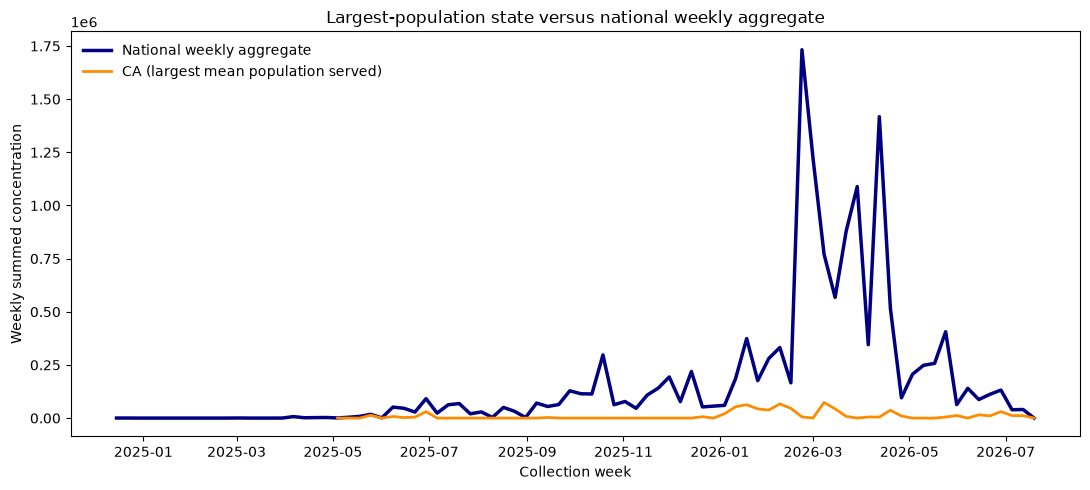

In [15]:
largest_state = (
    ww[ww['geography'].eq('state')]
    .groupby('state_territory')['population_served'].mean()
    .idxmax()
)
largest_state_weekly = state_weekly[
    state_weekly['state_territory'].eq(largest_state)
]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(national_aggregate_weekly['collection_date'],
        national_aggregate_weekly['pcr_target_avg_conc'],
        color='navy', linewidth=2.5, label='National weekly aggregate')
ax.plot(largest_state_weekly['collection_date'],
        largest_state_weekly['pcr_target_avg_conc'],
        color='darkorange', linewidth=2,
        label=f'{largest_state.upper()} (largest mean population served)')
ax.set(title='Largest-population state versus national weekly aggregate',
       xlabel='Collection week', ylabel='Weekly summed concentration')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## Step 4: sanity-check and save

> *Report how many sites reported per week recently and the latest sample date (to show*
> *the reporting lag), then save the weekly series to `measles_wastewater_weekly.csv`.*


In [17]:
weekly_site_counts = ww.attrs['weekly_national_sites']
weekly_national = (
    ww[ww['geography'].eq('national')]
    .groupby(pd.Grouper(key='collection_date', freq='W-SUN'), as_index=False)
    .agg(pcr_target_avg_conc=('pcr_target_avg_conc', 'sum'),
         population_served=('population_served', 'sum'))
    .merge(weekly_site_counts, on='collection_date', how='left')
)
print('sites reporting per week (last 6):')
display(weekly_national[['collection_date', 'n_sites_reporting']].tail(6))
print('latest sample date:', ww['collection_date'].max().date())
weekly_national.to_csv('measles__wastewater_weekly.csv', index=False)
print('saved measles__wastewater_weekly.csv', weekly_national.shape)


KeyError: 'weekly_national_sites'

## Reflection

- You described the outcome; the agent handled the messy CDC schema.
- Wastewater is biology, not behavior - a stream that fails differently from search.
- On your own: overlay against ILI and judge the lead time.
